# **Case do Café**

O cliente possui um processo interno de avaliação de qualidade que combina análises laboratoriais e características do processo de torra para determinar a qualidade final de cada lote de café.
Cada lote produzido passa por uma análise que gera diferentes indicadores físico-químicos e operacionais. A partir dessas medições, especialistas atribuem uma pontuação final de qualidade, representada pela variável SCORE

> **Problema:** falta de entendimento sobre quais fatores mais impactam a qualidade e como podem prever isso de forma consistente

> **Objetivo:** melhorar o controle do processo produtivo, otimizar decisões operacionais e garantir maior consistência na qualidade do produto

> **O que fazer:** explorar os dados disponíveis, compreender os fatores que influenciam a qualidade do café e desenvolver um modelo capaz de prever a pontuação de qualidade (SCORE)

A resolução deve ser estruturada em:
1. Análise Descritiva (o que aconteceu?)
2. Análise Diagnóstica (por que aconteceu?)
3. Análise Preditiva (o que vai acontecer?)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [3]:
df = pd.read_csv(r'coffee_score.csv')
df.head()

,aromatic_instability,brightness_compound,mineral_content,antioxidant_level,density,roast_intensity,market_segment,score
0,0.70,0.00,0.076,11.0,3.103366,9.4,tradicional,5.124179
1,0.88,0.00,0.098,25.0,2.103366,9.8,tradicional,4.965434
2,0.76,0.04,0.092,15.0,2.303366,9.8,tradicional,5.161922
3,0.28,0.56,0.075,17.0,3.303366,9.8,especial,6.380757
4,0.70,0.00,0.076,11.0,3.103366,9.4,tradicional,4.941462


In [4]:
df.shape

(6497, 8)

## **1. Análise Descritiva**

     O que aconteceu? 

Nesta etapa, eu explorei o conjunto de dados para identificar o **tipo das variáveis** e suas **distribuições**. Também observei **relações** entre elas. Por fim, destaquei **padrões** e possíveis **pontos‑problema** que poderiam impactar análises posteriores.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   aromatic_instability  6497 non-null   float64
 1   brightness_compound   6497 non-null   float64
 2   mineral_content       6497 non-null   float64
 3   antioxidant_level     6497 non-null   float64
 4   density               6497 non-null   float64
 5   roast_intensity       6497 non-null   float64
 6   market_segment        6497 non-null   object 
 7   score                 6497 non-null   float64
dtypes: float64(7), object(1)
memory usage: 406.2+ KB


#### **1.1 Descrição das variáveis**

| COLUNA | TIPO | DESCRIÇÃO |
|--------|------|-----------|
|aromatic_instability | float - contínua | indicador da instabilidade aromática do café |
| brightness_compound | float - contínua | presença de compostos associados à sensação sensorial de brilho e acidez percebida |
| 	mineral_content | float - contínua | concentração de minerais presentes no grão |
| antioxidant_level | float - contínua | nível de compostos antioxidantes presentes na amostra |
| density | float - contínua | densidade média dos grãos do lote |
| roast_intensity | float - contínua |  intensidade da torra aplicada ao café |
| market_segment | string - categórica |  segmento de mercado para o qual o café será direcionado |
| score | float - contínua | **TARGET** - pontuação de qualidade do lote de café |


##### Quais são as variáveis **controláveis** pelo processo?

     >>>>>> Levando em consideração que a fábrica **recebe seus grãos** (não cultiva nem colhe) ---- suposição

| COLUNA | CONTROLE | EXPLICAÇÃO |
|--------|------|-----------|
|aromatic_instability | não controlável | depende dos compostos formados naturalmente no grão |
| brightness_compound | não controlável | vem da composição ácida natural do café|
| mineral_content | não controlável | depende de solo, nutrição, variedade e terroir |
| antioxidant_level | não controlável | vem da química natural do grão |
| density | não controlável | definida por altitude, genética, maturação do fruto e secagem|
| roast_intensity | **``controlável``** | ajuste de temperatura, tempo e fluxo de ar --> fatores manipuláveis |
| market_segment | **``controlável``** | decisão estrtégica |

PS: Terroir do café é o conjunto de fatores naturais (solo, clima, altitude, precipitação, luz solar) e humanos (manejo, colheita, processamento)

##### **1.2 Resumo Descritivo dos Dados**

In [6]:
df.describe()

,aromatic_instability,brightness_compound,mineral_content,antioxidant_level,density,roast_intensity,score
count,6497.000000,6497.000000,6497.000000,6497.000000,6.497000e+03,6497.000000,6497.000000
mean,0.339666,0.318633,0.056034,30.525319,-1.056901e-14,10.491801,5.817170
std,0.164636,0.145318,0.035034,17.749400,2.998673e+00,1.192712,0.910991
min,0.080000,0.000000,0.009000,1.000000,-7.586634e+00,8.000000,2.620163
25%,0.230000,0.250000,0.038000,17.000000,-2.356634e+00,9.500000,5.087658
50%,0.290000,0.310000,0.047000,29.000000,1.933662e-01,10.300000,5.880589
75%,0.400000,0.390000,0.065000,41.000000,2.293366e+00,11.300000,6.291877
max,1.580000,1.660000,0.611000,289.000000,4.428337e+01,14.900000,9.180391


Interpretação:
- Score médio de 5.81 sugere que a qualidade geral dos cafés está mediana, com margem para melhorias
- Antioxidantes muito desbalanceados: a maioria dos cafés tem níveis normais (até 41), mas alguns apresentam valores extremamente altos (até 289)
- Densidade com padrão estranho: os valores sugerem que essa variável pode ter sido processada de forma diferente ou contém inconsistências nos dados.
- Conteúdo mineral muito variável: enquanto a maioria dos cafés tem baixo teor mineral, o máximo chega a ser mais de 10 vezes superior.

##### **1.3 Distribuição das Variáveis**

     Histograma 

Usei histogramas para visualizar a distribuição das variáveis, entender sua forma e identificar possíveis outliers ou distorções que poderiam influenciar as análises posteriores.

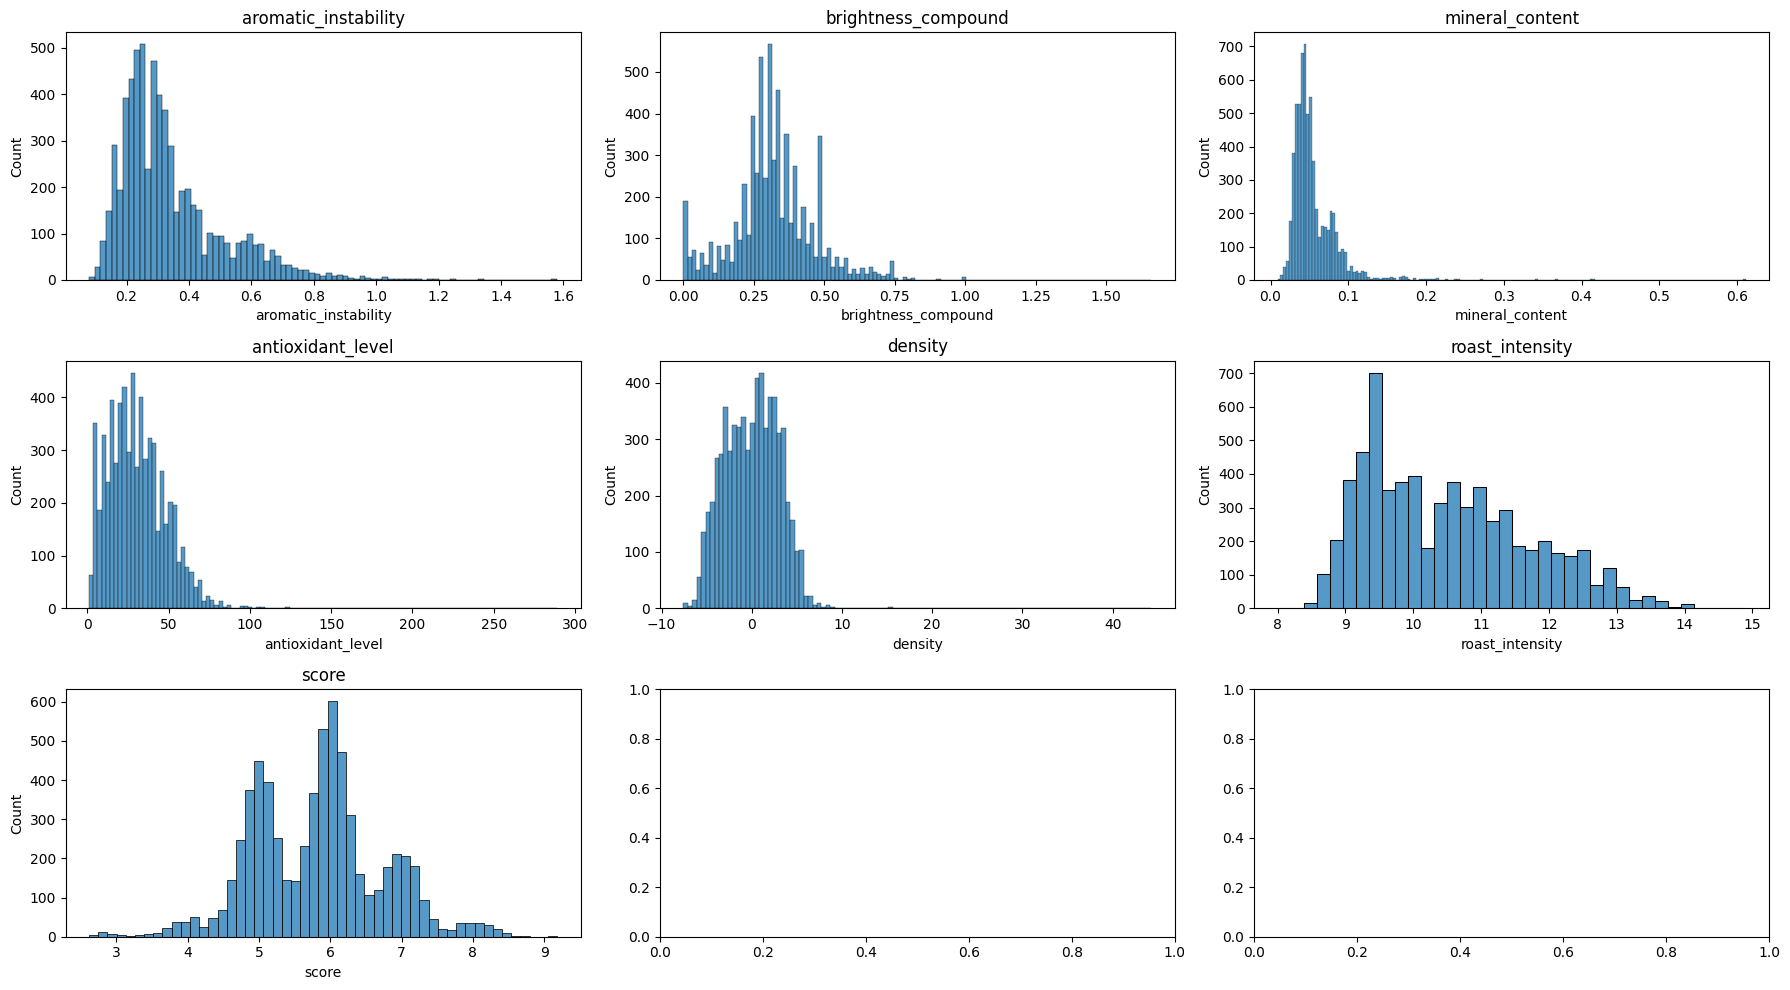

In [7]:
features = df.drop(columns="market_segment")

fig, axes = plt.subplots(3, 3, figsize=(18,10))
axes = axes.ravel()

for ax, col in zip(axes, features):
    sns.histplot(df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

##### **1.3.1 Interpretação Analítica**: 

- Nenhuma das distribuições são normais
- As variáveis em geral apresentam caudas longas, menos roast_intensity que aparenta ser bem controlada

**Score**:
- Tem picos distintos, indicando possíveis subgrupos dentro dos dados
- Maior densidade ~5–7, com frequência maior em ~6

> **Nota:** Ao analiser os histogramas, algo me chamou a atenção, ``densidade`` apresenta **valores negativos**, mas se considerarmos a formula `densidade = massa/volume` percebemos uma inconcistência, visto que na fisica não existe em termos gerais massa negativa. 

>> **Conclusão:** como não tenho informações sobre medida e origem destes dados, eu prossegui desta maneira. Mas caso fosse um case REAL, com certeza isso seria algo que eu pontuaria e correria atrás para entender melhor e consertar caso necessário 

##### **1.3.2 Interpretação de Negócio**: 
- Enxergamos que as variáveis não seguem um padrão, apresentando picos diferentes e valores muito distantes da média
- Todas os fatores apresentam uma grande variabilidade, indicando que os lotes não são padronizados e/ou necessita melhor controle de qualidade
- A presença de subgrupos no ``score`` sugere diferentes perfis de café no portfólio
- Valores impossíveis (como densidade negativa) indicam necessidade de informações sobre medida e origem dos dados para uma melhor compreensão
______________________

#### **1.4 Análise de Dispersão e Outliers**

Para a análise de dispersão e outliers será utilizado o gráfico de boxplot, que representa a distribuição de um conjunto de dados de forma visual e resumida. Nessa abordagem, os outlier serão considerados como limite superior para: `Q1 - 1.5 * IQR` e limite superior de `Q3 + 1.5 * IQR`

Onde:

- Q1 > quartil que representa 25% dos dados
- Q3 > quartil que representa 75% dos dados
- IQR > Intervalo entre quartis

> Este gráfico apresenta uma visualização estatísitica da distribuição, ele é voltado para a equipe de analytics e é menos voltado para negócios

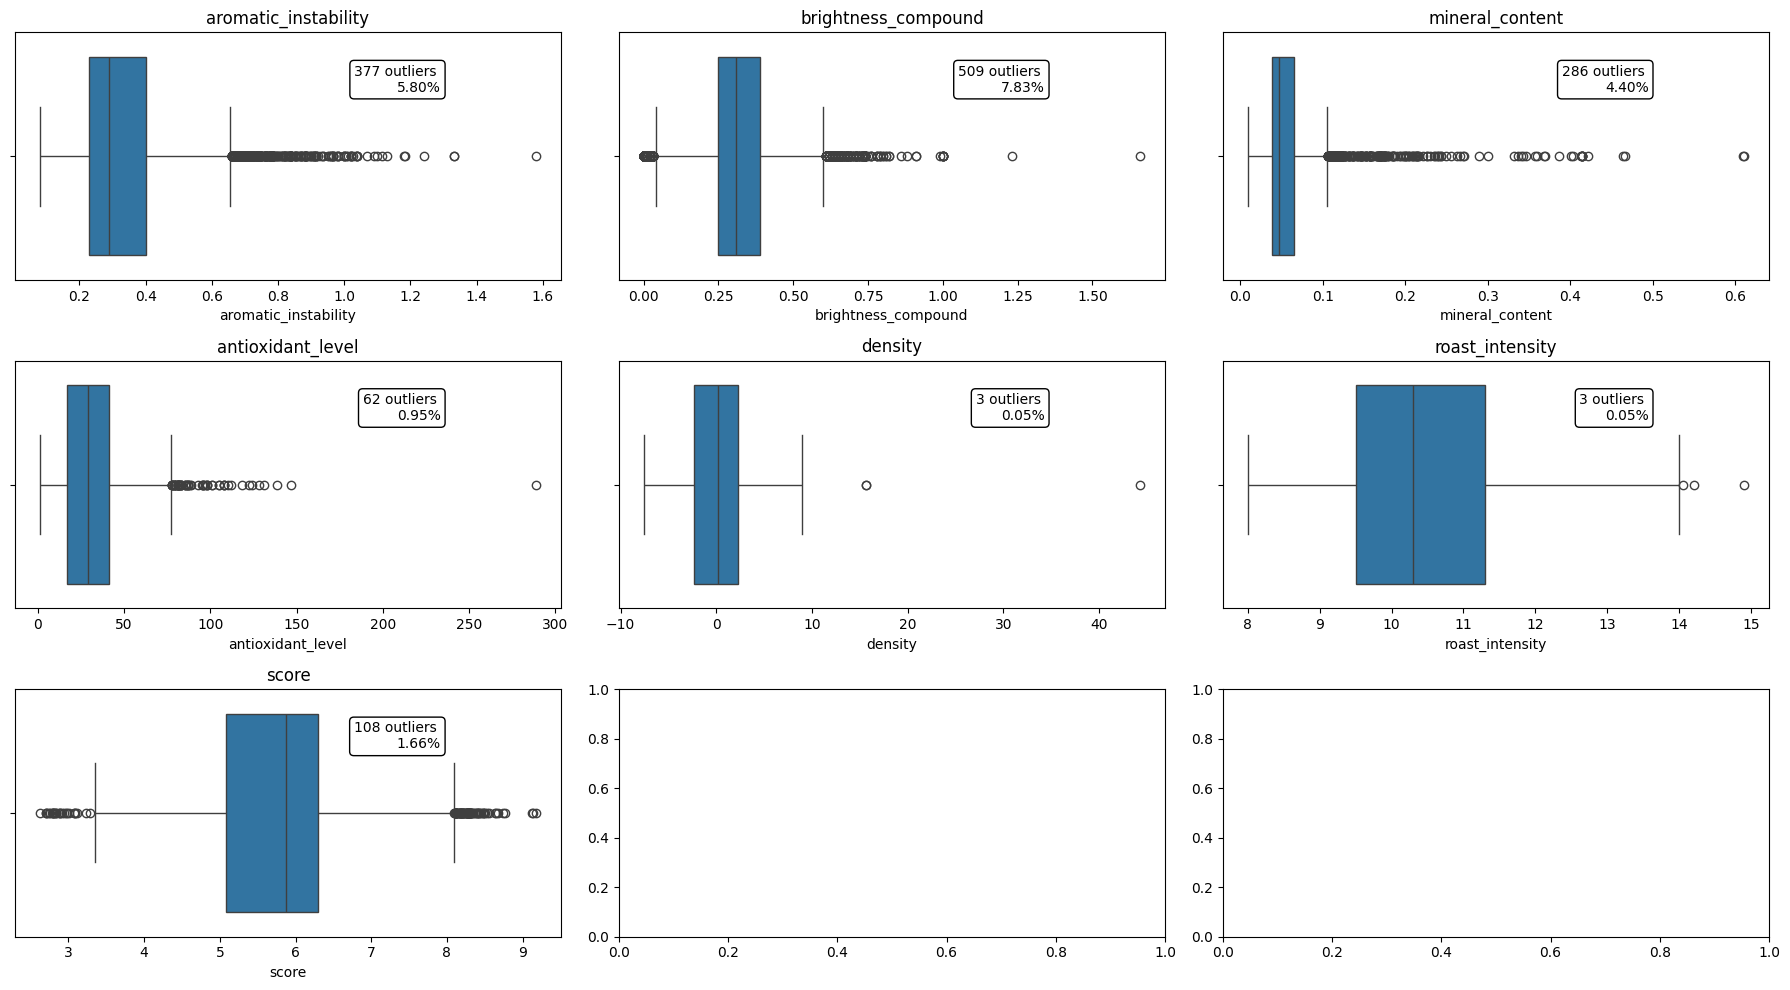

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(18,10))
axes = axes.ravel()

for ax, col in zip(axes, features):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    porcentagem = 100 * n_outliers / len(df)

    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(col)

    # caixa texto flutuante
    ax.text( 
    0.78, 0.87,
    f"{n_outliers} outliers \n{porcentagem:.2f}%",
    transform=ax.transAxes,
    ha="right", va="top", bbox=dict(boxstyle="round", facecolor="white"))

plt.tight_layout()
plt.show()

##### **1.4.1 Interpretação Analítica:**

- A maioria das variáveis tem cauda longa para a direita
- Tem muitos outliers
- ``Score`` e ``roast_intensity`` são as mais controladas

Variáveis com muitos outliers:
- antioxidant_level
- mineral_content
- brightness_compound
- aromatic_instability

##### **1.4.2 Interpretação de Negócio:**
- Muitos outliers indicam possíveis falhas de controle de qualidade ou inconsistências nos dados
- ``Torra (roast_intensity)`` é mais estável, mostrando melhor controle nessa etapa
_________________________________

##### **1.5 Relações entre variáveis**

**Heatmap:**

Utilizei heatmap para visualizar a correlação entre todas as variáveis numéricas do dataset
- Mede o quanto duas variáveis variam juntas
- Quanto mais forte a cor, maior a correlação
- **positiva:** quando uma sobe, a outra tende a subir
- **negativa:** quando uma sobe, a outra tende a cair

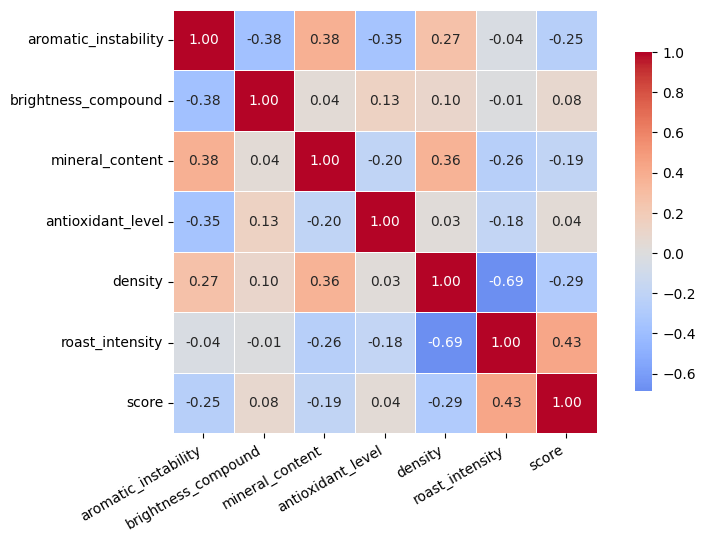

In [9]:
matriz_corr = features.corr(method='pearson')
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(matriz_corr, 
            annot=True,  fmt='.2f', # mostrar valores
            cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.xticks(rotation=30, ha='right')
plt.show()

##### **1.5.1 Principais Insights Analíticos:**
- `roast_intensity` é o fator mais relacionado à qualidade (0.43)
######
- `aromatic_instability` alta prejudica qualidade (-0.25)
######
- `density` alta prejudica qualidade (-0.29)
######
- `mineral_content` alto prejudica qualidade (-0.19)
######
- `density` alta prejudica a intensidade da `roast_intensity` (-0.69)

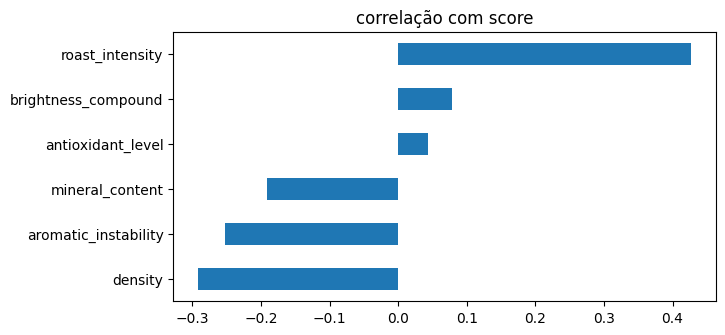

In [10]:
corr = df.corr(numeric_only=True)["score"].drop("score")

corr.sort_values().plot.barh(figsize=(7,3.5))
plt.title("correlação com score")
plt.show()

##### **1.5.2 Principais Insights de Negócio:**
- Quanto maior a intensidade da torra --> maior o score
- Quanto mais instáveis os compostos aromáticos, pior o score
- Quanto maior a quantidade de minerais, pior a qualidade do café
- Densidade alta tende a prejudicar a qualidade dos grãos

_________________________________
## **2. Análise Diagnóstica**

     por que aconteceu? 

Nesta etapa, identifiquei por que os padrões observados ocorreram, conectando achados estatísticos ao problema de negócio. Eu explorei relações e realizei pequenas recomendações para melhora.

#### **2.1 As features definem 100% do score?**

O score pode ser diferente com features idênticas?

In [11]:
features = df.drop(columns="score")
duplicados = df[df.duplicated(subset=features, keep=False)]
duplicados

,aromatic_instability,brightness_compound,mineral_content,antioxidant_level,density,roast_intensity,market_segment,score
0,0.700,0.00,0.076,11.0,3.103366,9.400000,tradicional,5.124179
4,0.700,0.00,0.076,11.0,3.103366,9.400000,tradicional,4.941462
9,0.500,0.36,0.071,17.0,3.103366,10.500000,tradicional,5.135640
11,0.500,0.36,0.071,17.0,3.103366,10.500000,tradicional,4.883568
22,0.430,0.21,0.106,10.0,1.903366,9.500000,tradicional,5.016882
...,...,...,...,...,...,...,...,...
6455,0.230,0.39,0.058,26.0,2.853366,9.000000,especial,5.748927
6478,0.340,0.40,0.046,68.0,0.243366,9.533333,especial,5.938993
6479,0.340,0.40,0.046,68.0,0.243366,9.533333,especial,6.073680
6480,0.235,0.27,0.030,34.0,0.703366,9.400000,especial,6.173304


##### **2.1.1 Interpretação Analítica:**
- O score varia, mesmo com valores idênticos nas features
- Sugere que existem outros fatores não medidos ou não presentes na tabela, que influenciam o score

##### **2.1.2 Interpretação de Negócio:**
- Com os mesmos valores nos fatores determinísticos, a qualidade ainda pode ser diferente
- Isso sugere que existem outros fatores determinísticos ocultos, não apresentados nos dados

____________
#### **2.2 Interação `density` x `roast_intensity`**

     Correlação (heatmap) = -0.69 

**Quando densidade aumenta, torra tende a diminuir**

Se a torra diminui, a qualidade tende a cair (correlação +0.43 de torra x score)

##### **2.2.1 Teste de hipótese:**

Densidade altera score de café com mesmo nível de torra?

     H0 = densidade NÃO tem efeito na torra 

     H1 = densidade TEM efeito sobre a torra 

O que vou medir?
- Coeficiente: ``quanto a variável dependente (torra) muda quando a variável explicativa (density) aumenta 1 unidade``
- p-valor: testa a hipótese de que o coeficiente é igual a zero (ou seja: não muda nada)
- R2: quanto da variação da variável dependente o modelo consegue explicar

In [12]:
from scipy.stats import t

dens = df["density"].values
roast = df["roast_intensity"].values
n_reg = len(dens)

media_dens = dens.mean()
media_roast = roast.mean()

# formula de regressão linear (coeficiente)
beta1 = np.sum((dens - media_dens)*(roast - media_roast)) / np.sum((dens - media_dens)**2)

# calculo do intercepto 
beta0 = media_roast - beta1 * media_dens

pred = beta0 + beta1*dens

r2 = r2_score(roast, pred)

# calculo erro pad beta1
residuos = roast - pred
soma_residuos = np.sum(residuos**2)

var_residuo = soma_residuos / (n_reg - 2)
std_beta1 = np.sqrt(var_residuo) / np.sqrt(np.sum((dens - media_dens)**2))

# calculo do t e p-valor
t_estat = beta1 / std_beta1 
p_val = 2 * (1 - t.cdf(abs(t_estat), df = n_reg - 2))

print("coeficiente:", beta1)
print("p-valor:", p_val)
print("r2:", r2)

###### Tudo isso poderia ter sido feito usando:
#model = smf.ols("roast_intensity ~ density", data=df).fit()
#coeficiente = model.params["density"]
#p_valor = model.pvalues["density"]
#r2 = model.rsquared
#print(f"coeficiente (density): {coeficiente:.4f}")
#print(f"p-valor: {p_valor:.4e}")
#print(f"R2: {r2:.3f}")

coeficiente: -0.27315060091840254
p-valor: 0.0
r2: 0.4716192742013732


##### **Interpretação Analítica:**
- quando density aumenta 1 unidade, roast_intensity diminui aproximadamente 0.27 unidades
- p-valor rejeita H0 --> densidade TEM efeito sobre a torra
- 47.2% da variação em roast_intensity é explicada pela density

> Os dados apontam para uma **relação** estatisticamente **significativa** entre as duas variáveis

##### **Interpretação de Negócio:**
- Quanto menor a densidade do grão, maior a torra e consequentemente maior a qualidade (Score)
- **Recomendação (caso possível)**: o ideal seria a seleção de lotes/fornecedores que apresentem grãos com densidades menores



____________
#### **2.3 Entendendo a coluna CATEGÓRICA - market_segment**

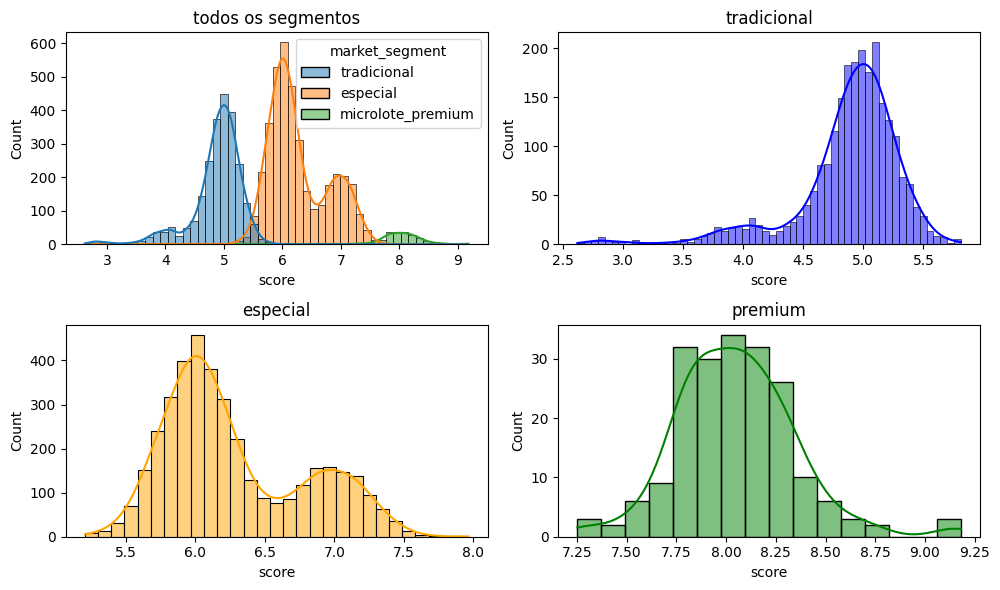

In [13]:
plt.figure(figsize=(10, 6))

# todos os segmentos
plt.subplot(2, 2, 1)
sns.histplot(data=df, x="score", hue="market_segment", kde=True)
plt.title("todos os segmentos")

# tradicional
plt.subplot(2, 2, 2)
sns.histplot( data=df[df["market_segment"] == "tradicional"], x="score", kde=True, color="blue")
plt.title("tradicional")

# especial
plt.subplot(2, 2, 3)
sns.histplot(data=df[df["market_segment"] == "especial"], x="score", kde=True, color="orange")
plt.title("especial")

# microlote premium
plt.subplot(2, 2, 4)
sns.histplot(data=df[df["market_segment"] == "microlote_premium"], x="score", kde=True, color="green")
plt.title("premium")

plt.tight_layout()
plt.show()

- A qualidade está muito bem separada entre os segmentos do café (com médias bem separadas)
- Existe algumas sobreposições, mas são poucas
- Enxergo **oportunidades de negócio nos picos e sobreposições**
- A maior parte dos lotes está em especial e tradicional
- **``Recomendação:``** dentro do segmento especial, indentifiquei dois picos diferentes, abrindo margem para a **criação de um segmento novo** (depois de 6.5), ou seja, sugerimos um produto novo com valor superior ao vendido atualmente no especial

In [14]:
df.groupby("market_segment")["score"].describe()

,count,mean,std,min,25%,50%,75%,max
market_segment,,,,,,,,
especial,3915.0,6.276648,0.505330,5.205824,5.909303,6.126755,6.680972,7.963183
microlote_premium,198.0,8.048924,0.300582,7.252216,7.847277,8.032204,8.218886,9.180391
tradicional,2384.0,4.877260,0.436948,2.620163,4.749263,4.956748,5.133086,5.810773


Tradicional: 2.62 - 5.81

Especial: 5.21 - 7.96

Premium: 7.25 - 9.18

_____________
##### **2.3.1 Teste de hipótese: segmentos vieram antes ou depois do SCORE?**
Como não tive acesso ao time de negócio, não posso afirmar com total certeza se a coluna ``market_segment`` foi definida antes ou depois da determinação do score.

Sabemos, no entanto, que:
- No padrão ABIC, a classificação de mercado é feita **depois** do processamento do grão e após a determinação da pontuação de qualidade (score).
- Já a classificação COB, baseada em características físicas do grão, ocorre **antes** da obtenção do score

###### Fonte: https://www.cafepoint.com.br/noticias/giro-de-noticias/entenda-sobre-o-novo-protocolo-de-classificacao-do-cafe-torrado-232690/ 

Como eu não tenho certeza que a coluna ``market_segment`` corresponde a segmentação do padrão ABIC, rodei um teste de hipótese para entender.

**Porque eu fiz essa etapa:**  
> Essa análise é fundamental para determinar se a variável ``market_segment`` **pode ser utilizada no modelo** ou é uma variável resultante, cuja utilização poderia ser um **data leak**
- - - - - - 
**Pergunta-chave: Segmentos foram criados a partir do score ou antes dele?**

Para responder a essa pergunta, estruturamos o teste de hipótese da seguinte forma:

     Hipótese Nula (H0): 
Não há diferença estatisticamente significativa entre os segmentos
- Qualquer diferença entre segmentos observada pode ser explicada pelo **acaso**
- Se F ~= 1, as diferenças entre grupos são pequenas e podem ser aleatórias
- p > 0.05, não rejeitamos H0 --> diferenças podem ter ocorrido por acaso
######
     Hipótese Alternativa (H1): 
Existe diferença estatisticamente significativa entre os segmentos
- A separação entre os segmentos é **maior do que a esperada pelo acaso**
- Se F é grande, as diferenças entre grupos são grandes demais para serem explicadas por acaso (variação externa > variação interna)
- p < 0.05 --> diferenças são improváveis de serem acaso

**``F-Statistic:``**

É uma medida de: o quanto os segmentos são realmente diferentes entre si

> F = (variância entre grupos) / (variância dentro dos grupos) 
- Se as médias dos grupos são muito diferentes, a variância entre os grupos aumenta --> F aumenta
- Se cada grupo tem pouca variação interna, ou seja, os dados dentro do grupo são parecidos --> F aumenta

In [15]:
from scipy.stats import f

score = df["score"].values
grupo = df["market_segment"].values

media_geral = score.mean()

sq_entre = 0
sq_dentro = 0
for g in df["market_segment"].unique():
    valores = score[grupo == g]
    media_g = valores.mean()

    # soma dos quadrados entre os grupos
    sq_entre += len(valores) * (media_g - media_geral)**2

    # soma dos quadrados dentro dos grupos
    sq_dentro += np.sum((valores - media_g)**2)

grupos = 3 # n grupos (tradicional, especial, premium) --- é o k
n = len(score)

# graus de liberdade
graus_entre = grupos - 1 
graus_dentro = n - grupos # compara variação interna

var_entre = sq_entre / graus_entre # variância entre os grupos
var_dentro = sq_dentro / graus_dentro # variância dentro dos grupos

f_estat = var_entre / var_dentro 
p_val = 1 - f.cdf(f_estat, graus_entre, graus_dentro)

print("f:", f_estat)
print("p:", p_val)

#### Também poderia ter sido feito usando:
#modelo = ols("score ~ C(market_segment)", data=df).fit()
#anova = sm.stats.anova_lm(modelo, typ=2)
#f_estat = anova.loc["C(market_segment)", "F"]
#p_valor = anova.loc["C(market_segment)", "PR(>F)"]
#print(f"f-statistic: {f_estat:.2f}")
#print(f"p-valor: {p_valor:.6f}")

f: 8642.867823447252
p: 1.1102230246251565e-16


>Nota: 1.11e-16 = 1.11 x 10^-16 = 0.00000...0000111 --> move a casa decimal 16 posições para a esquerda

**Interpretação Analítica:**
- O p-value mostra que a probabilidade desses segmentos terem essas diferenças por acaso é praticamente zero
- Estatística F mostra que os segmentos são muito diferentes entre si, com variação interna baixa e externa alta

**Interpretação de Negócio:**
- Conforme resultados, a probabilidade dos segmentos terem sido separados anteriormente ao score é praticamente 0
- Os segmentos são muito diferentes entre si, indicando segmentação posterior ao score

_____________________

**``Eta-Quadrado (eta²):``**

**É uma medida de tamanho do efeito que representa a proporção da variação total do score que é explicada pelos segmentos de mercado**

Quanto da variável dependente (score) é explicada pelo fator testado (market_segment)

     eta² = (soma dos quadrados do fator) / (soma total dos quadrados) 

- eta² de 0.01 representa efeito pequeno
- eta² de 0.06 representa efeito médio
- eta² de 0.14 representa efeito grande
- se for muito alto indica que grande parte da variação do score é explicada pelos segmentos

**NOTA**: Escolhi usar o Eta2 por **recomendação do Copilot**. Eu queria quantificar quanto da variância do score é explicada pelo market_segment e a medida se encaixa perfeitamente.

In [16]:
eta2 = sq_entre / (sq_entre + sq_dentro)
print("eta2:", eta2)

eta2: 0.7269103367493457


**Interpretação Analítica:**
- O eta² mostra que quase 73% da variância total do score é explicada por apenas uma variável categórica (market_segment)
- Isso reforça que os segmentos e o score não são independentes
- Essa variável provavelmente não está disponível no momento em que a fábrica precisaria prever o score

**Interpretação de Negócio:**
- Resultados indicam que a segmentação de mercado não reflete características de entrada do lote, mas sim uma decisão comercial baseada na qualidade (score)
- O segmento de mercado é provavelmente definido depois da pontuação (score) e não antes

##### **2.3.2 Conclusão**
- Os resultados apontam grande relação entre variáveis, o que tende a pensarmos que os segmentos foram definidos após o score
- Isso implica que ``market_segment`` não é uma informação disponível no momento em que a qualidade precisa ser prevista (o uso seria data leakage)
- A segmentação de mercado parece seguir uma lógica semelhante ao padrão ABIC, no qual a classificação é feita após determinar a pontuação de qualidade.
#####
Como **não temos confirmação oficial do cliente** sobre a origem e ordem da variável: 
- vou trabalhar com as duas hipóteses para garantir segurança e transparência na entrega
######
     Modelo sem market_segment: 
- Evita leakage
- Representa o cenário seguro e realista
- Útil para previsão operacional
######
     Modelo com market_segment: 
- Apenas para comparação e segurança na solução
- Mostra o impacto de ``market_segment``


###### Fontes: 
###### - Cap 3, pag 120 do livro "Estatística Prática para Cientistas de Dados" - Peter Bruce, Andrew Bruce & Peter Gedeck ---- Estatística F
###### - Cap 3, pag 117 do livro "Estatística Prática para Cientistas de Dados" - Peter Bruce, Andrew Bruce & Peter Gedeck ---- ANOVA
###### - How to Perform a One-Way ANOVA by Hand https://www.statology.org/one-way-anova-by-hand/
____________________

## **3. Processamento dos Dados**

Nesta etapa, foram realizadas as transformações necessárias para garantir qualidade, consistência e confiabilidade da base antes da modelagem
- Feature engineering, tratamento de outliers, duplicados etc

In [17]:
df.duplicated().sum()

np.int64(0)

### **3.1 Feature Engineering**

Criei features de relação entre variáveis a partir das correlações

1. ``density_roast``:
     - Conforme a análise vi que densidade e torra NÃO atuam de forma independente (-0.69 de correlação heatmap)
     - Criei uma variável de interação para capturar efeitos conjuntos entre densidade do grão e intensidade de torra
2. ``roast_quad``: 
     - A relação entre ``roast_intensity`` e o ``score`` não é linear
     - Criei uma feature polinomial de 2º grau para permitir que o modelo aprenda essa curvatura
######
     PS: Todos os testes de criação e validação das features podem ser encontrados no notebook "testes-case-cafe.ipynb", onde diferentes combinações foram avaliadas para medir impacto na performance.

In [18]:
df["density_roast"] = df["density"] * df["roast_intensity"]
df["roast_quad"] = df["roast_intensity"] ** 2

### **3.2 Transformação de dados**

>**Método utilizado: Yeo-johnson**

**Como funciona:**
- Aplica uma transformação de potência ajustada a cada variável
- Encontra automaticamente o parâmetro λ que produz a distribuição mais próxima da normal
- Funciona com valores negativos, positivos e 0

**Porque não apliquei no target:**
- O objetivo do modelo é prever diretamente o score original
- Transformar o target exigiria desfazer a transformação na etapa de previsão, o que adiciona complexidade
- Além disso, o score já apresentava uma distribuição utilizável sem necessidade de estabilização

##### **3.2.1 Porque NÃO apliquei em valores negativos?**
######
      Optei por não transformar variáveis que continham valores negativos que eram fisicamente **impossíveis** (density)
Motivos: 
- Testes mostraram melhor desempenho **sem** a transformação das variáveis negativas
- Transformações de potência em valores incorretos tendem a **amplificar o erro**, não corrigir
- No mundo real, densidade nunca é negativa 
######
     PS: Os testes completos de transformação (incluindo comparações de performance) estão no notebook "testes-case-cafe.ipynb"

###### NOTA: Eu ainda não havia utilizado a transformação Yeo‑Johnson. Um professor mencionou e testou o método recentemente em aula, e eu resolvi aplicar neste case (já que precisava de um método para testar com negativos e 0)

In [19]:
colunas_transformar = [c for c in df.columns if c not in ["market_segment", "score"] and (df[c] >= 0).all()]

from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson', standardize=False)
df[colunas_transformar] = pt.fit_transform(df[colunas_transformar])

df.describe()

,aromatic_instability,brightness_compound,mineral_content,antioxidant_level,density,roast_intensity,score,density_roast,roast_quad
count,6497.000000,6497.000000,6497.000000,6497.000000,6.497000e+03,6497.000000,6497.000000,6497.000000,6497.000000
mean,0.164213,0.278752,0.028873,7.606953,-1.056901e-14,0.481333,5.817170,-2.455803,1.069254
std,0.033256,0.115614,0.005674,2.588349,2.998673e+00,0.000653,0.910991,32.669064,0.002835
min,0.066423,0.000000,0.008087,0.809262,-7.586634e+00,0.479375,2.620163,-105.932874,1.060722
25%,0.141716,0.227885,0.024929,5.793091,-2.356634e+00,0.480793,5.087658,-25.883645,1.066909
50%,0.160989,0.276991,0.028212,7.810175,1.933662e-01,0.481325,5.880589,1.911642,1.069220
75%,0.186746,0.339700,0.033044,9.406412,2.293366e+00,0.481847,6.291877,22.110969,1.071485
max,0.248567,1.073967,0.042963,24.870628,4.428337e+01,0.482970,9.180391,518.115384,1.076362


##### **3.2.2 Distribuições e Outliers PÓS Transformação (yeo-johnson)**

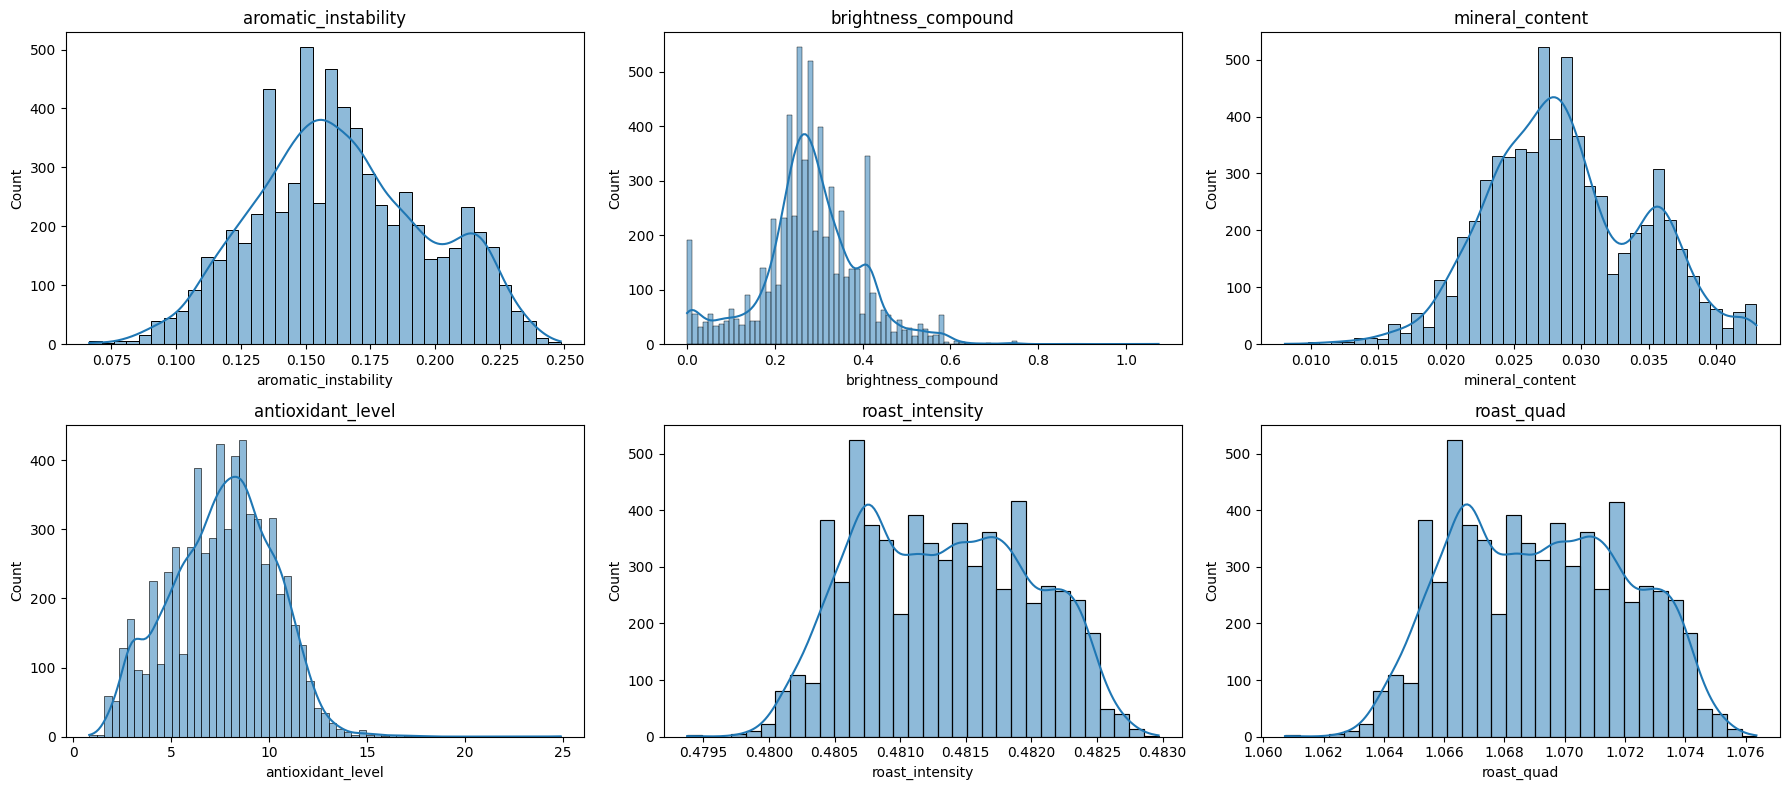

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()

for ax, col in zip(axes, colunas_transformar):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

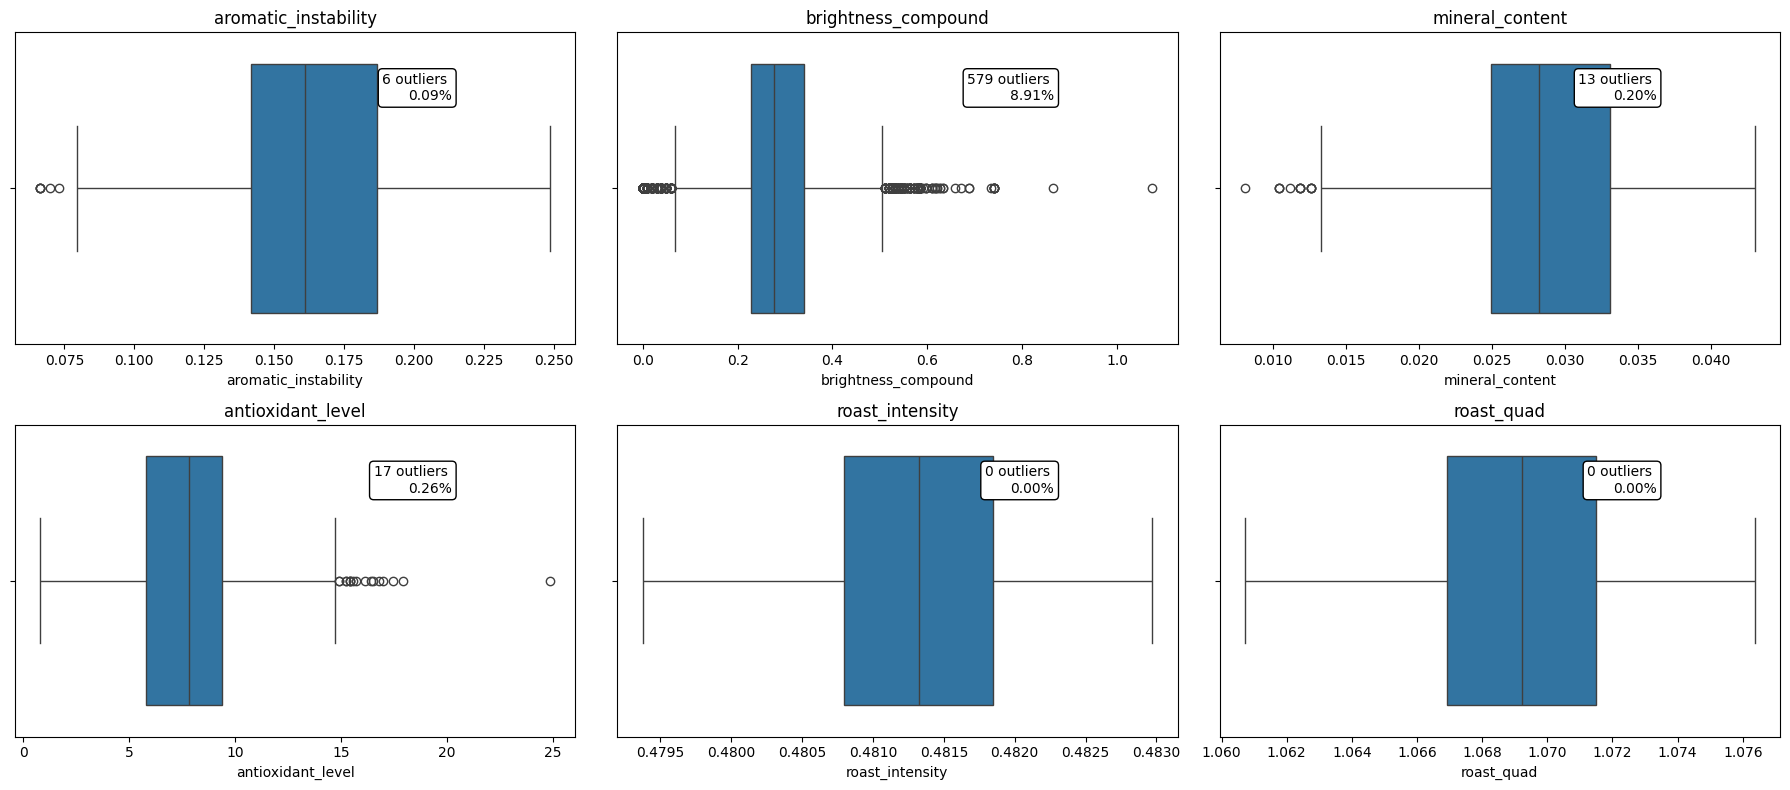

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18,8))
axes = axes.ravel()

for ax, col in zip(axes, colunas_transformar):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    porcentagem = 100 * n_outliers / len(df)

    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(col)

    # texto das caixinhas flutuantes
    ax.text( 
    0.78, 0.87,
    f"{n_outliers} outliers \n{porcentagem:.2f}%",
    transform=ax.transAxes,
    ha="right", va="top", bbox=dict(boxstyle="round", facecolor="white"))

plt.tight_layout()
plt.show()

##### **3.2.3 Remoção da variável brightness_compound**

Retirei a coluna ``brightness_compound`` porque ela apresentava diversos problemas que prejudicavam a modelagem, mesmo após o tratamento

Muitos outliers (antes e depois da transformação)
- A variável já possuía muitos outliers na distribuição original
- Diferentemente das outras variáveis, a transformação aumentou os outliers

Baixa relevância estatística:
- ``brightness_compound`` apresentou baixa correlação com todas as variáveis principais
- A única correlação notável foi -0.38 com ``aromatic_instability``

Piora na performance do modelo:
- Testei versões do modelo com e sem essa variável
- A performance foi melhor sem ela
######
     PS: registros do teste de remoção da variável estão no notebook "testes-case-cafe.ipynb"

In [22]:
df.drop(columns="brightness_compound", inplace=True)

____________________
### **3.3 Tratamento de Outliers**

Para identificar valores extremos entre variáveis de diferentes escalas, utilizei o método IQR (Interquartile Range)

Ele define outliers encontrando: lower e upper fences

IQR é o Q3 - Q1 (amplitude interquartil)

- Lower Fence = Q1 - 1.5 x IQR
- Upper Fence = Q3 + 1.5 x IQR

Outliers são: 
- valores **menores** que a lower fence 
- **maiores** que a upper fence

In [23]:
df_tratado = df.copy()
features = df_tratado.columns.drop(["market_segment", "score"])

for feature in features:
    Q1 = df_tratado[feature].quantile(0.25)
    Q3 = df_tratado[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    
    df_tratado = df_tratado[(df_tratado[feature] >= lower_fence) & (df_tratado[feature] <= upper_fence)]

df_tratado.shape

(6449, 9)

In [24]:
print("antes:", len(df))
print("depois:", len(df_tratado))
print("removidos:", len(df) - len(df_tratado))
print("porcentagem removida:", 100 * (len(df) - len(df_tratado)) / len(df), "%")

antes: 6497
depois: 6449
removidos: 48
porcentagem removida: 0.7388025242419578 %


_____________________________________________________________
## **4. Análise Preditiva**

     O que vai acontecer? 

"Dado as características do lote, qual será o score?""
 
Inferência estatística e modelos preditivos para representar o processo industrial e prever resultados

In [25]:
df_tratado.head()

,aromatic_instability,mineral_content,antioxidant_level,density,roast_intensity,market_segment,score,density_roast,roast_quad
0,0.223009,0.035154,4.482891,3.103366,0.480717,tradicional,5.124179,29.171642,1.066580
1,0.233364,0.038088,7.199127,2.103366,0.481006,tradicional,4.965434,20.612988,1.067838
2,0.227047,0.037425,5.388347,2.303366,0.481006,tradicional,5.161922,22.572988,1.067838
3,0.158081,0.034983,5.793091,3.303366,0.481006,especial,6.380757,32.372988,1.067838
4,0.223009,0.035154,4.482891,3.103366,0.480717,tradicional,4.941462,29.171642,1.066580


_________________
##### **IMPORTANTE !!!!**

Para garantir segurança da solução, serão desenvolvidos dois modelos, mas **>somente 1<** será utilizado em produção.

Modelo A (sem ``market_segment``):
- Análise diagnóstica mostrou forte evidência de que o score é definido antes do market_segment
- Usar market_segment como feature configuraria leakage

Modelo B (com ``market_segment``):
- Será feito para garantir segurança na solução, pois não há confirmação 100% do cliente sobre a ordem real de definição da variável
_____________________

### **4.1 Modelo A**
- Não utiliza a variável ``market_segment``
- A análise diagnóstica indica fortemente que ``market_segment`` é derivada do ``score``
- Usar essa variável **configuraria leakage**

Esse modelo deve ser aplicado depois da torra e anteriormente a definição de segmento de mercado

#### **4.1.1 Separação entre features e target** 

- **X:** variáveis de entrada (informações disponíveis durante o processo)  
- **y:** variável de saída (score final que queremos prever)

Como o Modelo A não utiliza ``market_segment`` por conta do risco de leakage identificado antes, essa coluna foi removida do conjunto de entrada

In [26]:
X_df = df_tratado.drop(columns=["score", "market_segment"]).copy()
y = df_tratado["score"].copy()

#### **4.1.2 Separação entre treino e teste** 

Antes de treinar qualquer modelo, separamos os dados em dois conjuntos:

- **Treino (80%)**: usado para o modelo aprender padrões entre variáveis do processo
- **Teste (20%)**: usado para avaliar o modelo em dados **não vistos**, simulando o cenário real da fábrica

Após a divisão treino/teste, garantimos que o target (`y`) esteja no formato esperado: **vetor 1D**

In [27]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42)

y_train = np.asarray(y_train).ravel()
y_test  = np.asarray(y_test).ravel()

#### **4.1.3 Benchmark de Modelos**
      Teste de modelos diferentes e comparação de desempenho 

**Métricas utilizadas:**
- **MAE** (Mean Absolute Error): erro médio absoluto (em gramas)  
- **RMSE** (Root Mean Squared Error): penaliza mais erros grandes, porque eleva ao quadrado
- **R²:** quanto da variação do peso o modelo explica (0 a 1; maior é melhor) -> R² = 1 - (soma dos resíduos² / soma das variações²)

In [28]:
modelos = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor()}

resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train_df, y_train)
    preds = modelo.predict(X_test_df)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    resultados.append({
        "model": nome,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2})

benchmark = pd.DataFrame(resultados).sort_values("R2", ascending=False)
benchmark

,model,RMSE,MAE,R2
3,Random Forest,0.657940,0.500171,0.441360
4,Gradient Boosting,0.719837,0.569636,0.331304
0,Linear Regression,0.751395,0.593294,0.271387
1,Ridge,0.801562,0.637664,0.170848
2,Lasso,0.826712,0.657123,0.117999
5,KNN,0.842268,0.648333,0.084495


O modelo que performou melhor no benchmark foi o ``Random Forest Regressor``

Como funciona:
- Ele constrói diversas árvores de decisão independentes
- Cada árvore recebe uma amostra aleatória dos dados (com reposição) e faz uma previsão
- A previsão final é a média das previsões de todas as árvores

______________
#### **4.1.4 Optuna - tuning de hiperparâmetros**
Utilizei **Optuna** para encontrar hiperparâmetros que melhoram desempenho

Ele faz vários experimentos, testa combinações e busca minimizar o erro com critério estatístico — em vez de tentativa e erro manual.

Como funciona?
- Eu defino um conjunto de hiperparâmetros possíveis
- O Optuna cria várias tentativas (trials)
- Cada trial testa uma combinação diferente
- O objetivo é maximizar o R2
- No final ele retorna o melhor R2 e os hiperparâmetros usados pra chegar no melhor R2

###### NOTA: Quem me apresentou o Optuna foi o meu tutor

In [29]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING) # desativa logs

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": 42,
        "n_jobs": -1}

    model = RandomForestRegressor(**params)
    model.fit(X_train_df, y_train)
    preds = model.predict(X_test_df)

    r2 = r2_score(y_test, preds)

    return r2

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))

study.optimize(objective, n_trials=100, show_progress_bar=True)

print("melhor r2:", study.best_value)
print("melhores params:")
print(study.best_params)

  0%|          | 0/100 [00:00<?, ?it/s]

melhor r2: 0.44336805584212535
melhores params:
{'n_estimators': 700, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}


#### **4.1.5 Modelo Final**

``Random Forest Regressor`` utilizando os **hiperparâmetros encontrados pelo Optuna** visando o maior R2 possível

In [30]:
parametros_optuna = study.best_params

rf_final = RandomForestRegressor(
    **parametros_optuna,
    random_state=42,
    n_jobs=-1)

rf_final.fit(X_train_df, y_train)

preds = rf_final.predict(X_test_df)

print("R2:", r2_score(y_test, preds))
print("rmse:", np.sqrt(mean_squared_error(y_test, preds)))
print("mae:", mean_absolute_error(y_test, preds))

R2: 0.44336805584212535
rmse: 0.656755817458427
mae: 0.5018047134022819


##### **4.1.6 Resultados do Modelo**
- Erro médio de 0.50
- Erro quadrático médio de 0.65
- R2 de 0.44

##### **4.1.5 Interpretação de Negócio:**

Dadas as variáveis ``roast_intensity, density, aromatic_instability, antioxidant_level, mineral_content`` conseguimos criar um modelo preditivo que prevê o valor de score com apenas 0.5 de erro, o que é útil para antecipar qualidade antes da avaliação sensorial

Esse modelo deve ser aplicado depois da torra e anteriormente a definição de segmento de mercado

- O RMSE mostra que mesmo os erros maiores ainda são moderados
- Um R2 de 0.44 indica que o modelo está capturando uma parte significativa do processo

________________
### **4.2 Modelo B**
- Inclui market_segment como feature
- Criado para garantir segurança na solução, pois não há confirmação 100% do cliente sobre a ordem real de ``market_segment``
- Esse modelo ajuda a demonstrar o impacto da variável categórica, diferença de performance e importância da informação sobre ordem

Este modelo só deve ser aplicado depois da definição do segmento de mercado (market_segment)

#### **4.2.1 Transformação da var categórica - get-dummies** 

A variável `market_segment` é **categórica** 
Modelos de machine learning trabalham com valores **numéricos**, então precisamos transformar categorias em variáveis numéricas

O método utilizado foi one-hot encoding, que:
- cria uma nova coluna para cada categoria possível
- preenche com 1 quando o registro pertence à categoria
- preenche com 0 quando não pertence

In [31]:
df_modelob = df_tratado.copy()
df_modelob = pd.get_dummies(df_modelob, columns=['market_segment'], drop_first=False)

##### **4.2.2 Remoção de Features** (features novas adicionadas pro Modelo A)
Realizei testes (resultados registrados no notebook ``testes-case-cafe.ipynb``) e

Verifiquei que o Modelo B (com market_segment), apresentou melhor desempenho sem as features novas criadas no Modelo A:
- density_roast
- roast_quad

In [32]:
df_modelob.drop(columns=["density_roast", "roast_quad"], inplace=True)

#### **4.2.3 Separação entre features e target**
- **X:** variáveis de entrada (informações disponíveis durante o processo)  
- **y:** variável de saída (score final que queremos prever)

Como o Modelo B utiliza ``market_segment``, essa coluna permanece na entrada do modelo (diferentemente do modelo A, onde eu retirei)

In [33]:
X_df = df_modelob.drop(columns=["score"]).copy()
y = df_modelob["score"].copy()

#### **4.2.4 Separação entre treino e teste**
Antes de treinar qualquer modelo, separamos os dados em dois conjuntos:

- **Treino (80%)**: usado para o modelo aprender padrões entre variáveis do processo
- **Teste (20%)**: usado para avaliar o modelo em dados **não vistos**, simulando o cenário real da fábrica

Após a divisão treino/teste, garantimos que o target (`y`) esteja no formato esperado: **vetor 1D**

In [34]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42)

y_train = np.asarray(y_train).ravel()
y_test  = np.asarray(y_test).ravel()

#### **4.2.5 Benchmark de Modelos**
      Teste de modelos diferentes e comparação de desempenho 

**Métricas utilizadas:**
- **MAE** (Mean Absolute Error): erro médio absoluto (em gramas)  
- **RMSE** (Root Mean Squared Error): penaliza mais erros grandes, porque eleva ao quadrado
- **R²:** quanto da variação do peso o modelo explica (0 a 1; maior é melhor) -> R² = 1 - (soma dos resíduos² / soma das variações²)

In [35]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor()}

results = []

for name, model in models.items():
    model.fit(X_train_df, y_train)
    preds = model.predict(X_test_df)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results.append({
        "model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2})

benchmark = pd.DataFrame(results).sort_values("R2", ascending=False)
benchmark

,model,RMSE,MAE,R2
3,Random Forest,0.414445,0.322609,0.778337
4,Gradient Boosting,0.425471,0.333192,0.766385
0,Linear Regression,0.440253,0.348855,0.749871
1,Ridge,0.444519,0.351803,0.745000
5,KNN,0.477208,0.370219,0.706117
2,Lasso,0.880865,0.696671,-0.001334


O modelo que performou melhor no benchmark foi o ``Random Forest Regressor``

Como funciona:
- Ele constrói diversas árvores de decisão independentes
- Cada árvore recebe uma amostra aleatória dos dados (com reposição) e faz uma previsão
- A previsão final é a média das previsões de todas as árvores
_________________

#### **4.2.6 Tuning de hiperparâmetros - Optuna**
Utilizei **Optuna** para encontrar hiperparâmetros que melhoram desempenho

Ele faz vários experimentos, testa combinações e busca minimizar o erro com critério estatístico — em vez de tentativa e erro manual.

Como funciona?
- Eu defino um conjunto de hiperparâmetros possíveis
- O Optuna cria várias tentativas (trials)
- Cada trial testa uma combinação diferente
- O objetivo é maximizar o R2
- No final ele retorna o melhor R2 e os hiperparâmetros usados pra chegar no melhor R2

In [36]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": 42,
        "n_jobs": -1}

    model = RandomForestRegressor(**params)

    model.fit(X_train_df, y_train)
    preds = model.predict(X_test_df)

    r2 = r2_score(y_test, preds)
    return r2

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("melhor R2:", study.best_value)
print("melhores params:")
print(study.best_params)

  0%|          | 0/100 [00:00<?, ?it/s]

melhor R2: 0.7881247630436082
melhores params:
{'n_estimators': 1200, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


#### **4.2.7 Modelo Final**

``Random Forest Regressor`` utilizando os **hiperparâmetros encontrados pelo Optuna** visando o maior R2 possível

In [37]:
parametros_optuna = study.best_params

rf_final = RandomForestRegressor(
    **parametros_optuna,
    random_state=42,
    n_jobs=-1)

rf_final.fit(X_train_df, y_train)
preds = rf_final.predict(X_test_df)

print("R2 final:", r2_score(y_test, preds))
print("rmse final:", np.sqrt(mean_squared_error(y_test, preds)))
print("mae final:", mean_absolute_error(y_test, preds))

R2 final: 0.7881247630436082
rmse final: 0.4051911638356119
mae final: 0.31623066848882003


#### **4.2.8 Resultados do Modelo B**
- Erro médio de 0.31
- Erro quadrático médio de 0.40
- R2 de 0.78

**Interpretação de Negócio:**
Dadas as variáveis ``roast_intensity, density, aromatic_instability, antioxidant_level, mineral_content e market_segment`` conseguimos criar um modelo preditivo que prevê o valor de score com apenas 0.3 de erro, o que é útil para antecipar qualidade antes da avaliação sensorial

Este modelo só deve ser aplicado depois da definição do segmento de mercado (market_segment)

- O RMSE mostra que mesmo os erros maiores ainda são pequenos (abaixo de 0.5)
- Um R2 de 0.78 indica que o modelo está capturando grande do processo, principalmente porque conta com uma variável extremamente informativa (market_segment)
- Este desempenho reforça que market_segment carrega informação diretamente relacionada à qualidade

_______________
#### **4.2.9 Importância das Variáveis (Modelo B)**
Abaixo está o ranking de importância das variáveis do Random Forest Regressor no Modelo B:

In [38]:
importancia = pd.Series(
    rf_final.feature_importances_,
    index=X_train_df.columns).sort_values(ascending=False)

print(importancia)

market_segment_tradicional          0.333630
market_segment_especial             0.209336
market_segment_microlote_premium    0.109626
roast_intensity                     0.092476
density                             0.075932
aromatic_instability                0.061508
mineral_content                     0.061150
antioxidant_level                   0.056343
dtype: float64


##### **Interpretação:**
- As três categorias de ``market_segment`` aparecem no topo do ranking de importância pro modelo
- ``market_segment`` soma quase 70% da importância total do modelo
- Todas as demais variáveis juntas respondem por apenas ~30% da importância

O modelo está altamente dependente dessa informação, prevendo o score praticamente a partir somente disso


______________________
### **5. Recomendação para uma Análise Prescritiva:**

Para complementar o projeto, seria interessante a identificação de um ponto ótimo de torra para cada lote (levando em consideração as características dele).

Este ponto ótimo seria fundamental para a melhoria na qualidade dos lotes de café, já que a torra é o único fator controlável pela fábrica.

______________________________
### **6. Conclusão Final do Projeto**

#### **6.1 Contexto e Problema**

O cliente enfrentava:
- Falta de clareza sobre quais fatores mais influenciam a qualidade do café 
- Falta de meios para prever consistentemente o score final dos lotes antes da avaliação sensorial

Essa incerteza impactava decisões de produção, consistência do produto e direcionamento de mercado.
#### **6.2 Conclusão por Etapa**

Conclusões da Análise Descritiva:
- Identifiquei variáveis controláveis e não controláveis pelo processo
- As variáveis apresentaram distribuições assimétricas, presença de outliers e comportamento heterogêneo entre lotes
- O score possui múltiplos picos, sugerindo subgrupos de cafés
- Variável density apresentou comportamento atípicos (revisão da origem e tratamento dos dados)

Conclusões da Análise Diagnóstica:
- Identifiquei que o score pode variar mesmo com valores idênticos nas features, indicando a presença de fatores externos ou não presentes nos dados que afetam o score
- Testes estatísticos mostraram que densidade impacta a intensidade da torra (que consequentemente impacta o score)
- Testes estatísticos mostraram que market_segment explica ~73% da variância do score -> indicando extrema relação

Conclusões do Processamento de Dados:
- A partir de testes foram criadas features novas que auxiliaram o Modelo A a perfomar melhor
- A partir de testes foi aplicada a transformação Yeo Johnson aos dados positivos (ou iguais a 0)
- Foram retirados 48 outliers do dataset utilizando o método IQR
- A coluna brightness_compound foi retirada 

Conclusões da Análise Preditiva:
- Foram criados 2 modelos: um sem market_segment (A) e um contendo a variável categórica (B)
- O modelo A (evita leakage) apresentou um erro médio de 0.5
- O modelo B apresentou um erro médio de 0.3
- market_segment domina 70% da importância do modelo B
_______________
### **6.3 Conclusão Geral**
O modelo preditivo final fornece previsões antecipadas com desempenho consistente, auxiliando o negócio em:
- identificar lotes com potencial de alta qualidade
- melhorar a consistência dos produtos
- reduzir incertezas operacionais
- apoiar decisões de direcionamento comercial

##### O projeto atingiu **plenamente** o objetivo:

> Compreender os fatores que influenciam a qualidade e desenvolver um modelo robusto e confiável para prever o score antes da análise sensorial

Esse resultado fortalece o controle do processo produtivo, permite maior consistência na qualidade final e cria base sólida para automação e tomada de decisão orientada a dados.
##
     Para um próximo passo: 
- Sugerimos uma **análise prescritiva para ajustar o processo de torra de forma mais estratégica**
_____________

### Bibliografia:

- Livro Estatística Prática para Cientistas de Dados - Peter Bruce, Andrew Bruce e Peter Gedeck
- Associação Brasileira da Indústria de Café | ABIC
- Metodologia CRISP-DM (Cross-Industry Standard Process for Data Mining)
- Livro Estatística e Ciência de Dados - Pedro A. Morettin, Julio M. Singer (USP)
- Conteúdos e aulas da minha graduação em Ciência de Dados
- [Statology](https://www.statology.org/) 
- [GeeksforGeeks](https://www.geeksforgeeks.org/)

Obrigada